In [3]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
# 1. Count images per class and split
dataset_path = Path(os.getenv("DATA_DIR"))
records = []
for split in ["train", "valid"]:
    for class_name in os.listdir(dataset_path / split):
        folder = dataset_path / split / class_name
        count = len(list(folder.glob("*")))
        label = "fresh" if "fresh" in class_name else "rotten"
        fruit = class_name.replace("fresh", "").replace("rotten", "")
        records.append({"split": split, "class": class_name,
                        "fruit": fruit, "label": label, "count": count})

df = pd.DataFrame(records)
print(df)

    split          class    fruit   label  count
0   train   rottenapples   apples  rotten    770
1   train  rottenoranges  oranges  rotten    695
2   train   freshoranges  oranges   fresh    743
3   train   rottenbanana   banana  rotten    715
4   train    freshapples   apples   fresh    697
5   train    freshbanana   banana   fresh    625
6   valid   rottenapples   apples  rotten    177
7   valid  rottenoranges  oranges  rotten    178
8   valid   freshoranges  oranges   fresh    203
9   valid   rottenbanana   banana  rotten    177
10  valid    freshapples   apples   fresh    172
11  valid    freshbanana   banana   fresh    155


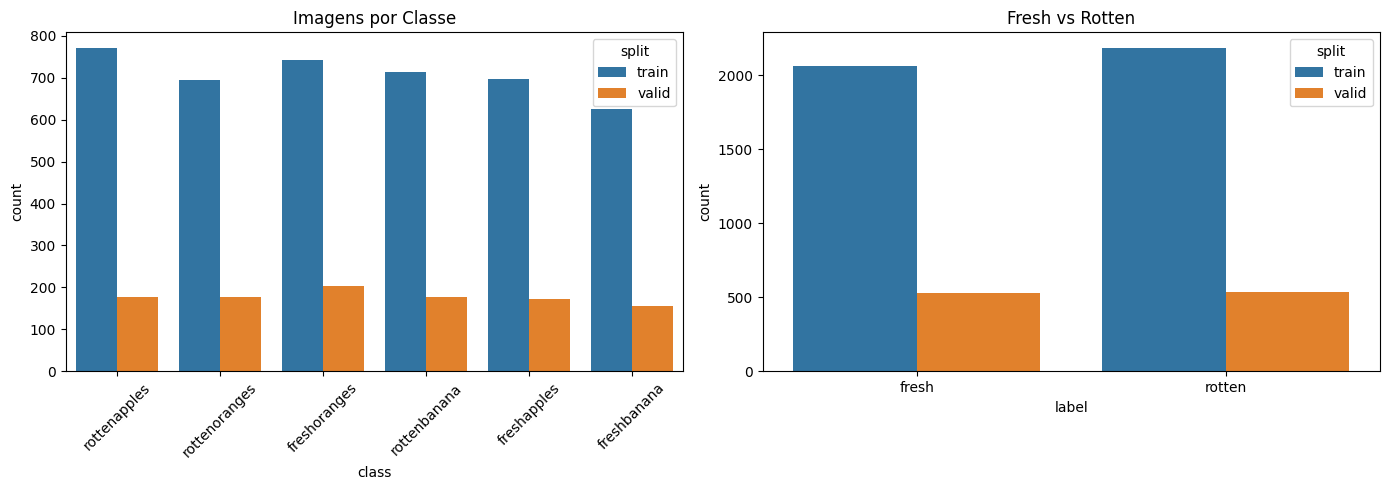

In [ ]:
# 2. Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x="class", y="count", hue="split", ax=axes[0])
axes[0].set_title("Imagens por Classe")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df.groupby(["split","label"])["count"]
            .sum().reset_index(),
            x="label", y="count", hue="split", ax=axes[1])
axes[1].set_title("Fresh vs Rotten")
plt.tight_layout()
plt.show()

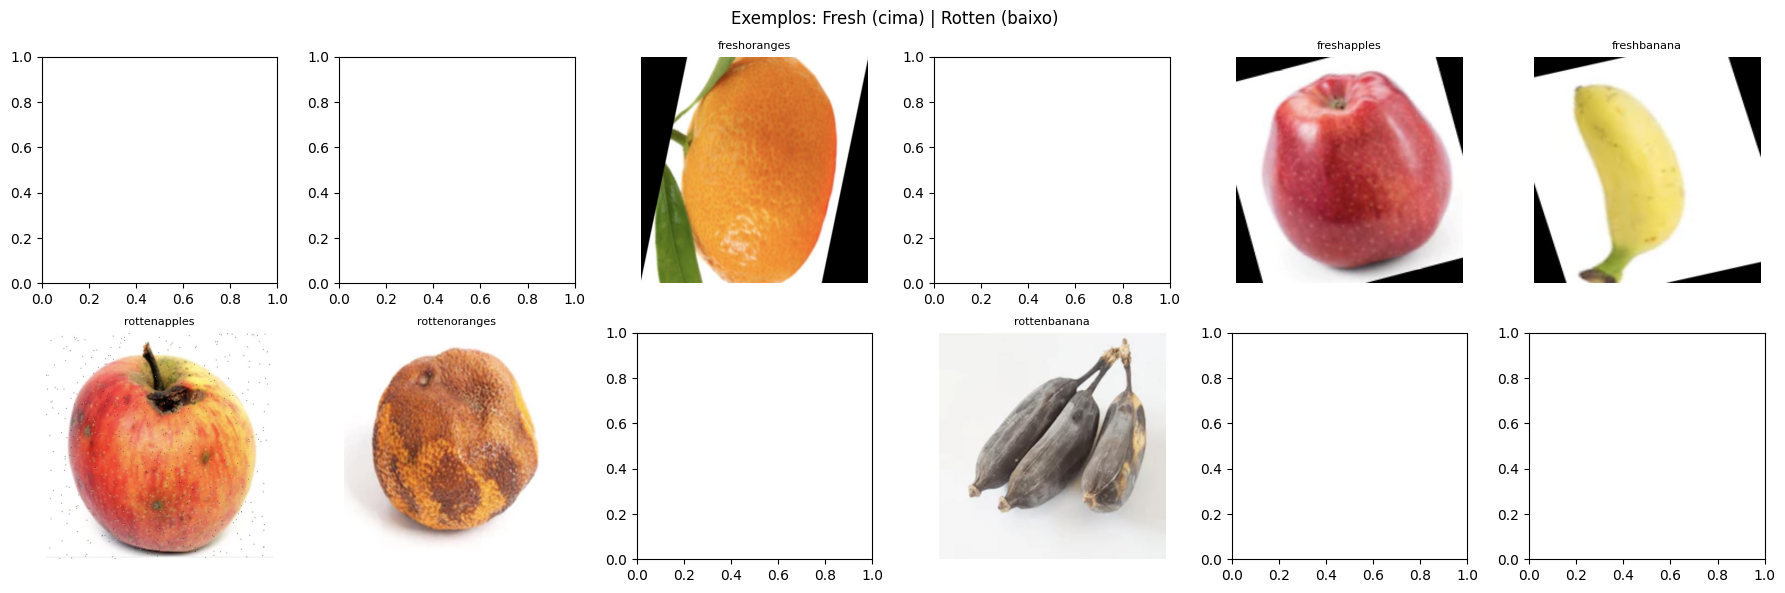

In [ ]:
# 3. Visualize some examples
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for idx, row in df[df["split"] == "train"].iterrows():
    folder = dataset_path / "train" / row["class"]
    img_path = list(folder.glob("*"))[0]
    img = Image.open(img_path)
    ax = axes[0 if row["label"] == "fresh" else 1][idx % 6]
    ax.imshow(img)
    ax.set_title(row["class"], fontsize=8)
    ax.axis("off")

plt.suptitle("Exemplos: Fresh (cima) | Rotten (baixo)")
plt.tight_layout()
plt.show()

In [ ]:
# 4. Verify image sizes 
sizes = []
for img_path in (dataset_path / "train").rglob("*.*"):
    with Image.open(img_path) as img:
        sizes.append(img.size)

widths, heights = zip(*sizes)
print(f"Largura: min={min(widths)}, max={max(widths)}, média={np.mean(widths):.0f}")
print(f"Altura:  min={min(heights)}, max={max(heights)}, média={np.mean(heights):.0f}")

Largura: min=640, max=640, média=640
Altura:  min=640, max=640, média=640
